## Fetching Data

First step would be to fetch the data from the Postgrees DB


In [1]:
import pandas as pd
import sqlalchemy
from dotenv import load_dotenv
import os

load_dotenv()

pg_url = (
    f"postgresql+psycopg2://{os.environ['PGUSER']}:{os.environ['PGPASSWORD']}"
    f"@{os.environ.get('PGHOST', 'localhost')}:{os.environ.get('PGPORT', '5432')}/"
    f"{os.environ['PGDATABASE']}"
)
engine = sqlalchemy.create_engine(pg_url, pool_pre_ping=True)

crimes_df = pd.read_sql("SELECT * FROM clean_chicago_crimes", engine)
moon_df = pd.read_sql("SELECT * FROM clean_moon_phases", engine)


In [2]:
print("Crimes Dataset Columns:", crimes_df.columns)
print("\n\nMoon Dataset Columns:", moon_df.columns)

Crimes Dataset Columns: Index(['id', 'date_only', 'primary_type', 'location_description', 'arrest',
       'domestic', 'crime_count'],
      dtype='object')


Moon Dataset Columns: Index(['time', 'year', 'age', 'phase', 'diameter', 'distance', 'phase_str'], dtype='object')


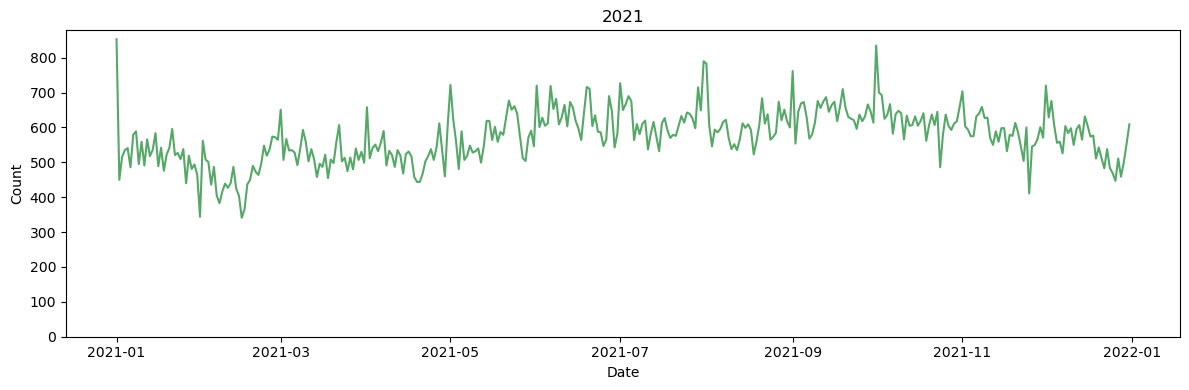

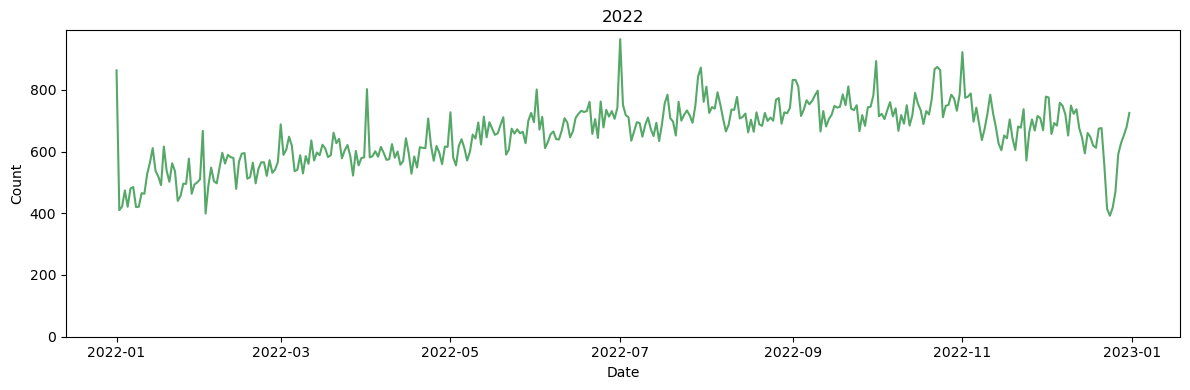

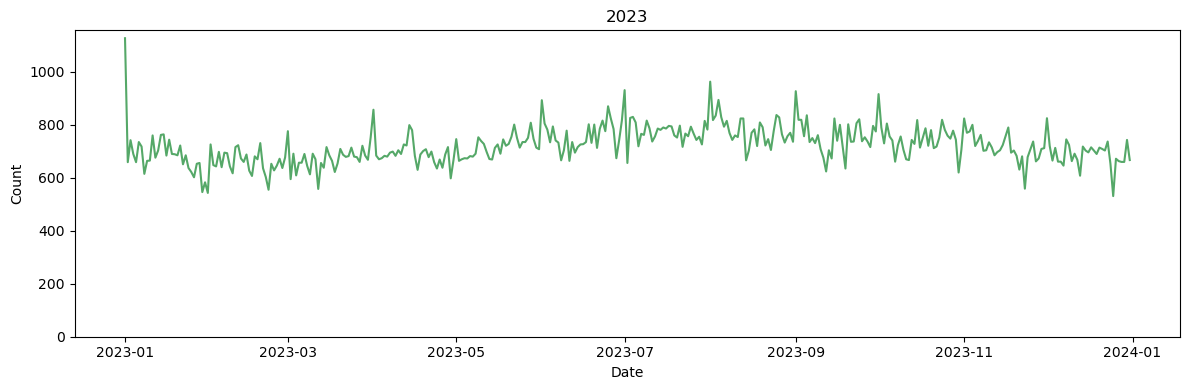

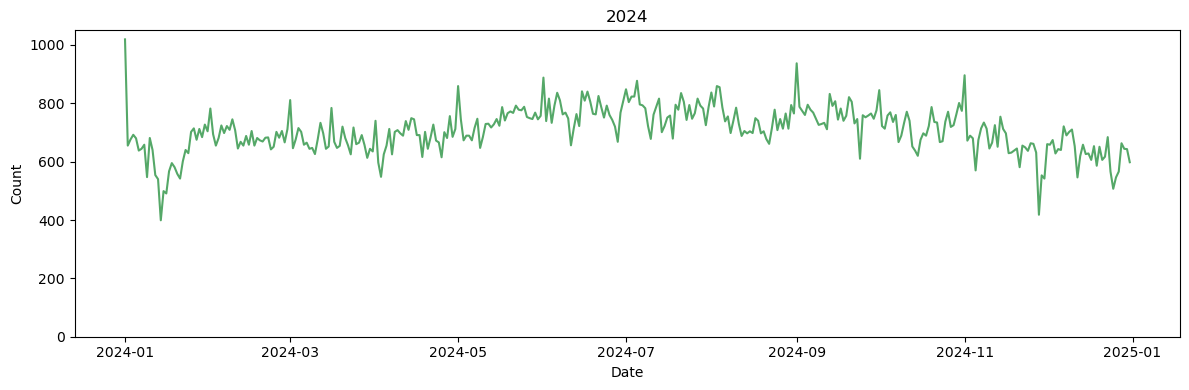

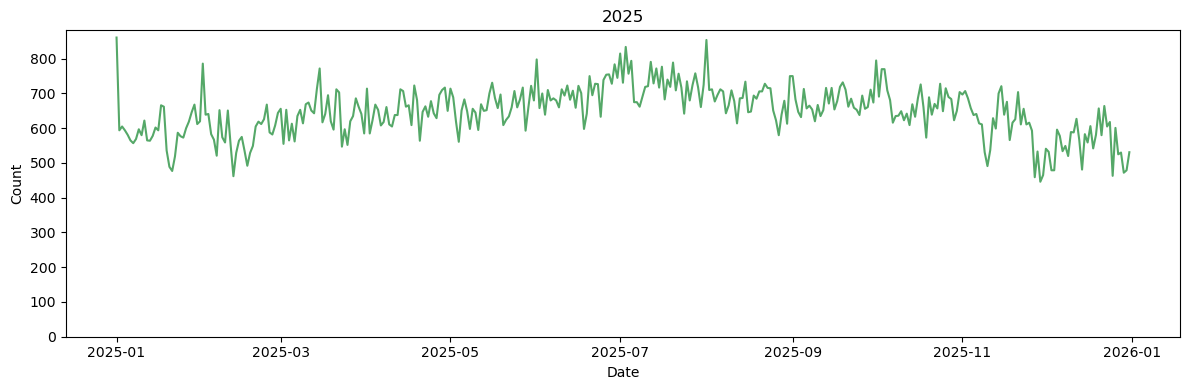

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Daily trend
years = [2021, 2022, 2023, 2024, 2025]

for y in years:
    crimes_by_day = (
        crimes_df.assign(date_only=pd.to_datetime(crimes_df["date_only"]))
        .loc[lambda d: d["date_only"].dt.year == y]
        .groupby("date_only")["crime_count"].sum()
        .reset_index()
        .sort_values("date_only")
    )

    plt.figure(figsize=(12, 4))
    sns.lineplot(data=crimes_by_day, x="date_only", y="crime_count", color="#55A868")
    plt.title(y)
    plt.xlabel("Date")
    plt.ylabel("Count")
    plt.ylim(bottom=0)
    plt.tight_layout()
    plt.show()

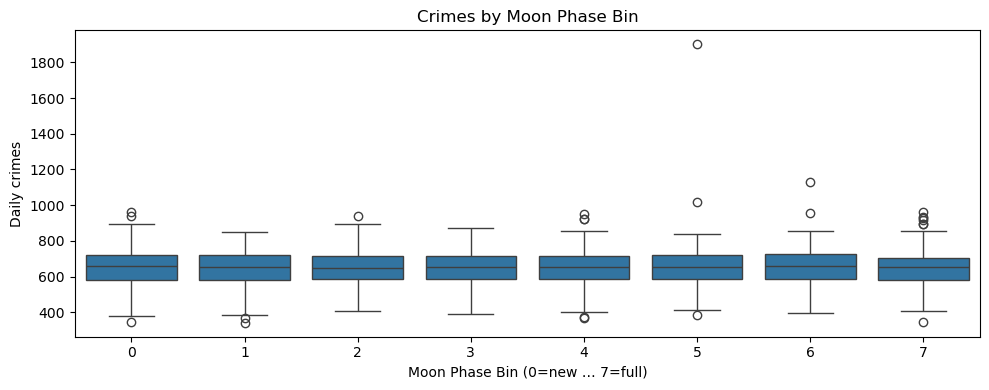

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

crimes_daily = crimes_df.groupby("date_only")["crime_count"].sum().reset_index().rename(columns={"date_only":"date"})

crimes_daily["date"] = pd.to_datetime(crimes_daily["date"])
moon_df["date"] = pd.to_datetime(moon_df["time"])

merged = (
    moon_df
    .merge(crimes_daily, on="date", how="left")
)

# Bin phase into 8 buckets (0–1 range)
merged["phase_bin"] = pd.cut(merged["phase"], bins=8, labels=False)

# Boxplot by phase_bin
plt.figure(figsize=(10,4))
sns.boxplot(data=merged, x="phase_bin", y="crime_count")
plt.title("Crimes by Moon Phase Bin")
plt.xlabel("Moon Phase Bin (0=new … 7=full)")
plt.ylabel("Daily crimes")
plt.tight_layout()
plt.show()


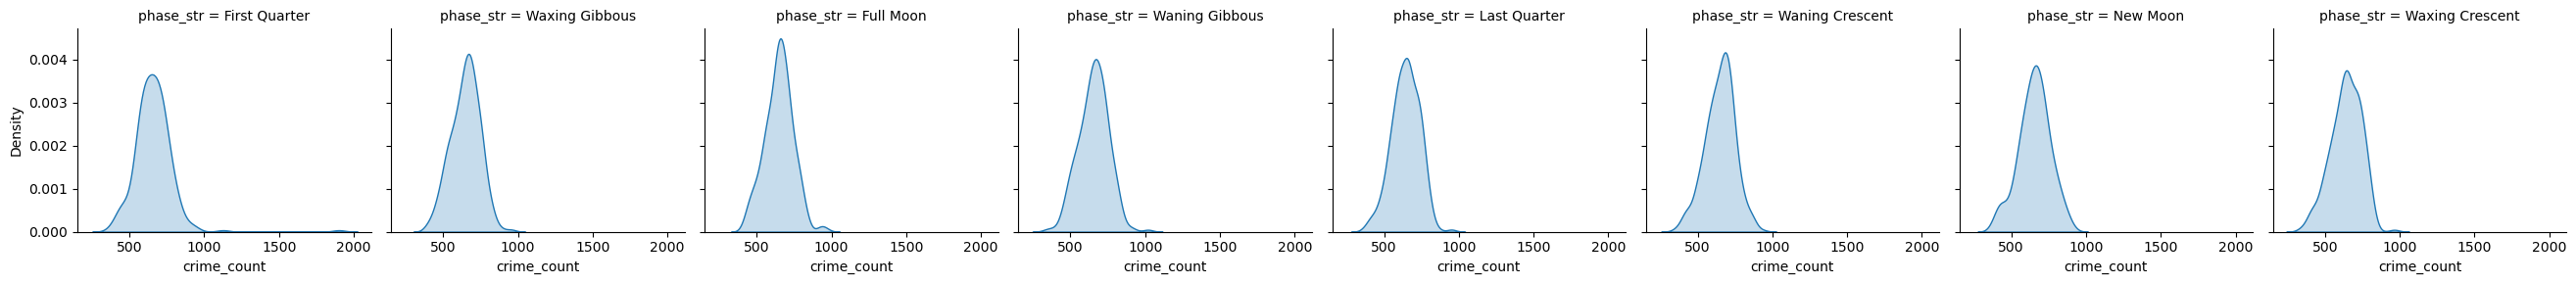

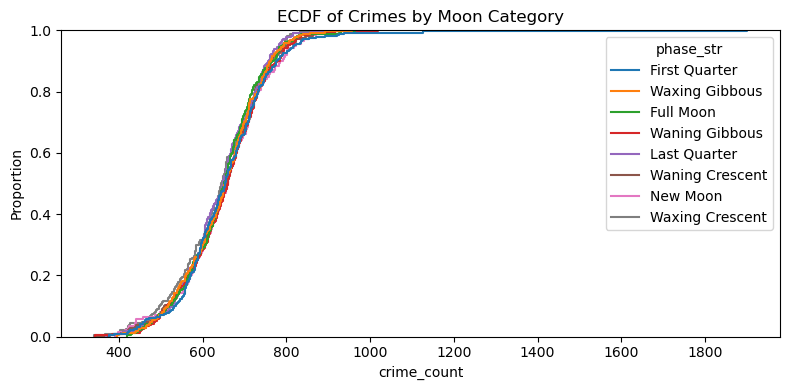

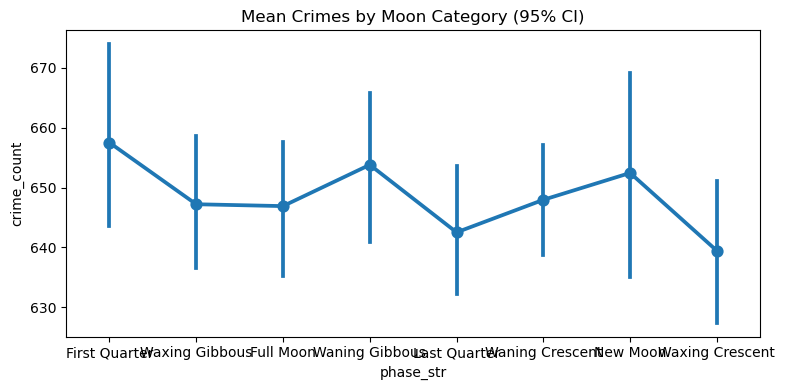

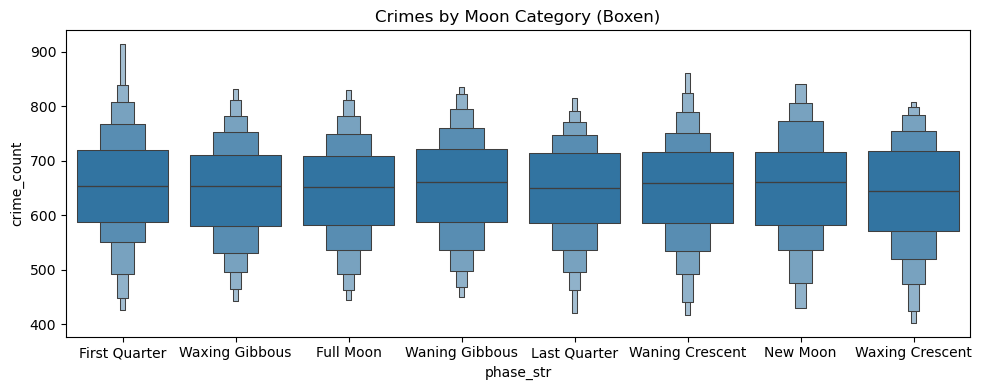

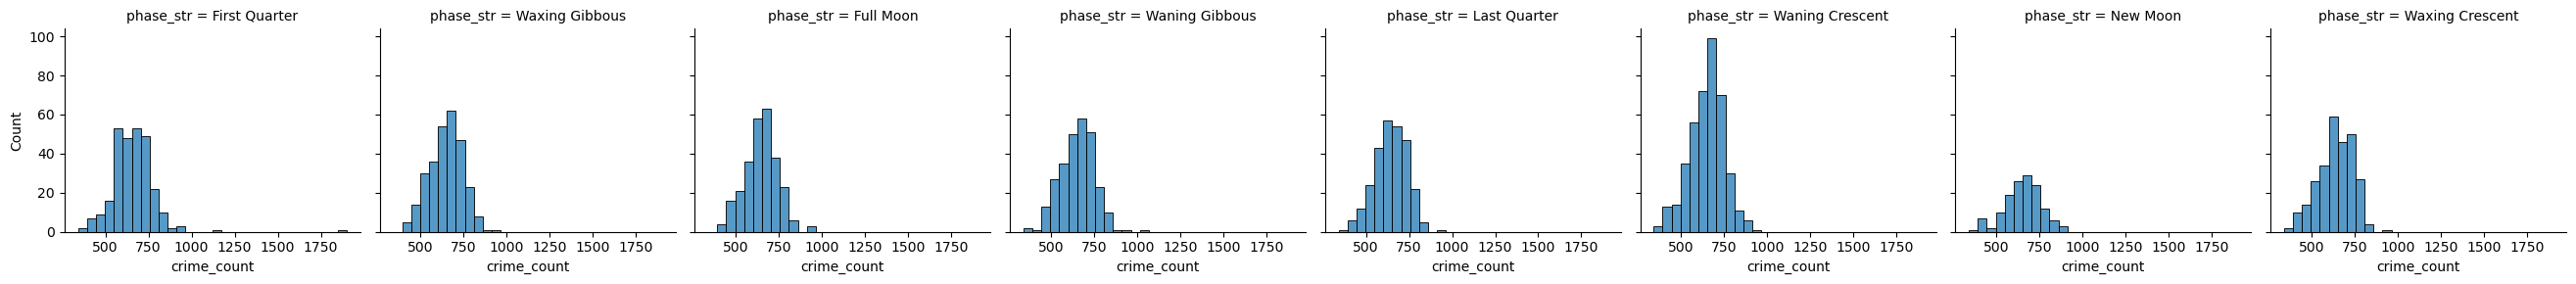

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# KDE facets
sns.displot(data=merged, x="crime_count", col="phase_str",
            kind="kde", fill=True, common_norm=False, height=3, aspect=1.1)

# ECDF
plt.figure(figsize=(8, 4))
sns.ecdfplot(data=merged, x="crime_count", hue="phase_str")
plt.title("ECDF of Crimes by Moon Category")
plt.tight_layout()

# Point plot (mean + 95% CI)
plt.figure(figsize=(8, 4))
sns.pointplot(data=merged, x="phase_str", y="crime_count",
              estimator=np.mean, errorbar=("ci", 95))
plt.title("Mean Crimes by Moon Category (95% CI)")
plt.tight_layout()

# Boxen plot (more quantiles)
plt.figure(figsize=(10, 4))
sns.boxenplot(data=merged, x="phase_str", y="crime_count", showfliers=False)
plt.title("Crimes by Moon Category (Boxen)")
plt.tight_layout()

# Histogram facets
sns.displot(data=merged, x="crime_count", col="phase_str",
            bins=30, common_bins=True, height=3, aspect=1.1)

plt.show()


Original days: 2192
Days after removing outliers: 2170


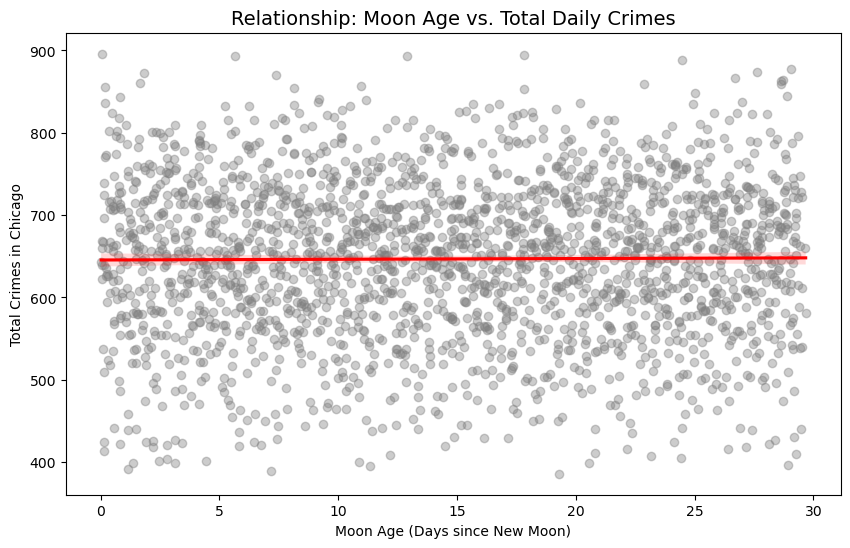

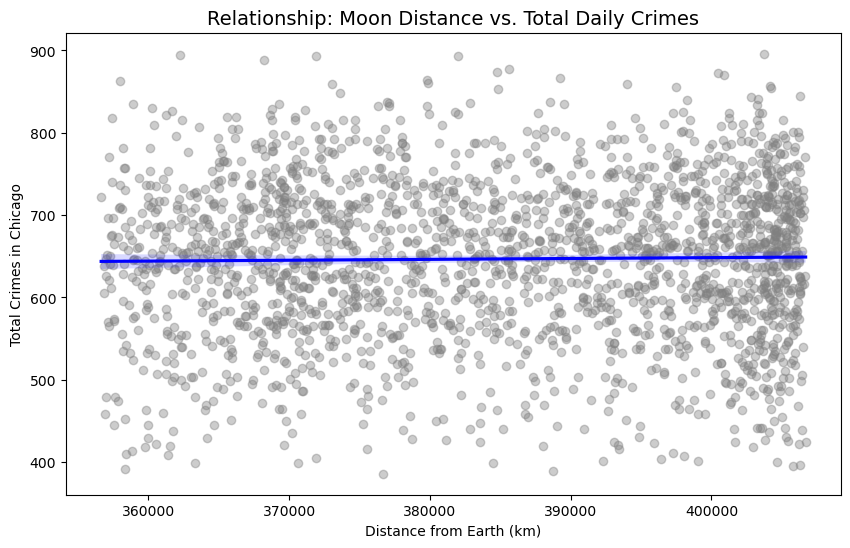

In [28]:
daily_summary = merged.groupby('date_only').agg({
    'crime_count': 'sum',   
    'age': 'first',         
    'distance': 'first',    
    'phase_str': 'first'
}).reset_index()

Q1 = daily_summary['crime_count'].quantile(0.25)
Q3 = daily_summary['crime_count'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

daily_filtered = daily_summary[
    (daily_summary['crime_count'] >= lower_bound) & 
    (daily_summary['crime_count'] <= upper_bound)
]

print(f"Original days: {len(daily_summary)}")
print(f"Days after removing outliers: {len(daily_filtered)}")

plt.figure(figsize=(10, 6))
sns.regplot(
    data=daily_filtered, 
    x="age", 
    y="crime_count", 
    scatter_kws={'alpha':0.4, 'color':'gray'}, 
    line_kws={'color':'red'}                   
)
plt.title("Relationship: Moon Age vs. Total Daily Crimes", fontsize=14)
plt.xlabel("Moon Age (Days since New Moon)")
plt.ylabel("Total Crimes in Chicago")
plt.show()

plt.figure(figsize=(10, 6))
sns.regplot(
    data=daily_filtered, 
    x="distance", 
    y="crime_count", 
    scatter_kws={'alpha':0.4, 'color':'gray'},
    line_kws={'color':'blue'}
)
plt.title("Relationship: Moon Distance vs. Total Daily Crimes", fontsize=14)
plt.xlabel("Distance from Earth (km)")
plt.ylabel("Total Crimes in Chicago")
plt.show()

C:\Users\renat\AppData\Local\Temp\ipykernel_29296\4091705326.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Blues')


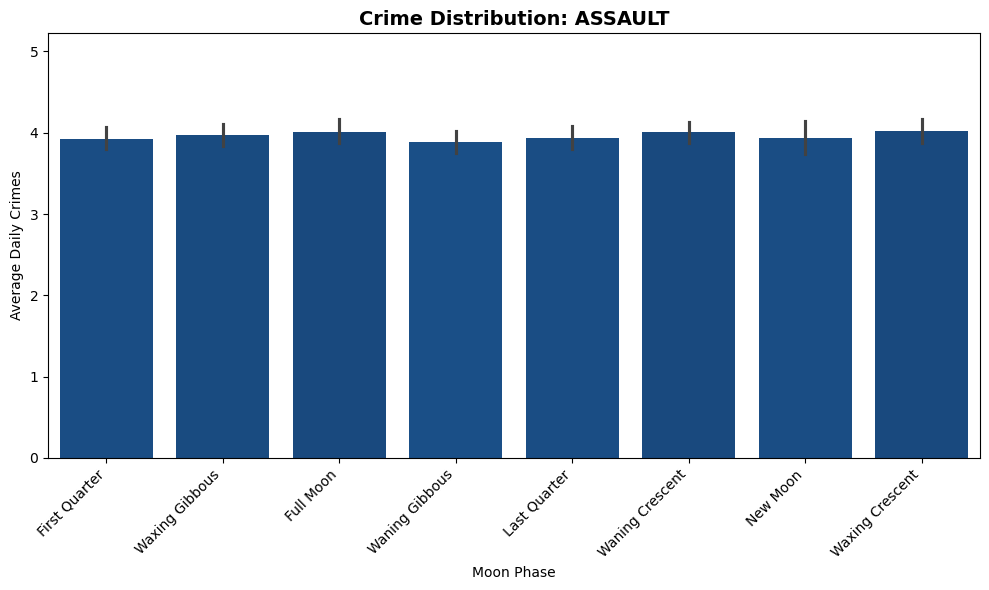

C:\Users\renat\AppData\Local\Temp\ipykernel_29296\4091705326.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Blues')


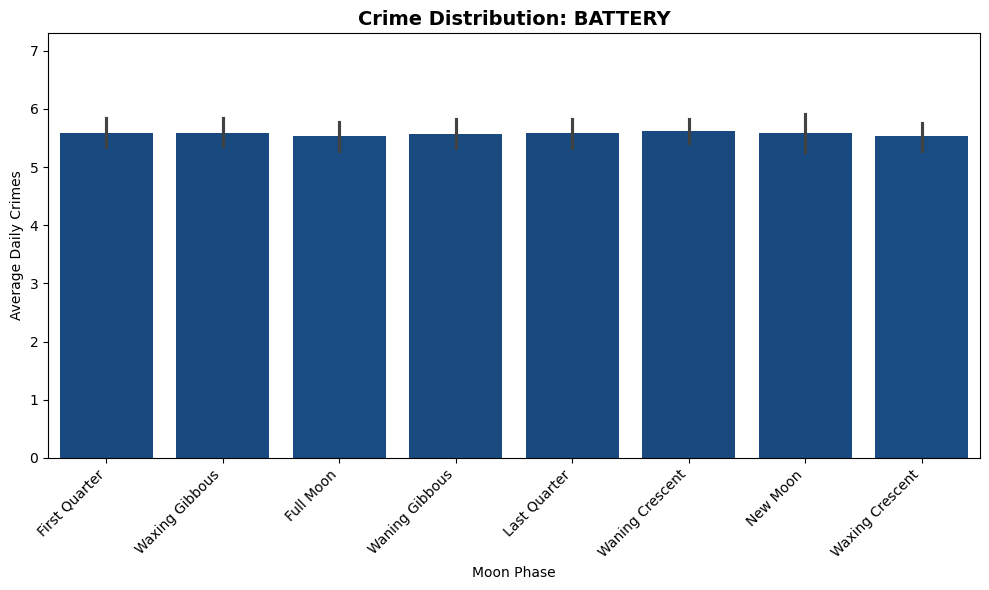

C:\Users\renat\AppData\Local\Temp\ipykernel_29296\4091705326.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Blues')


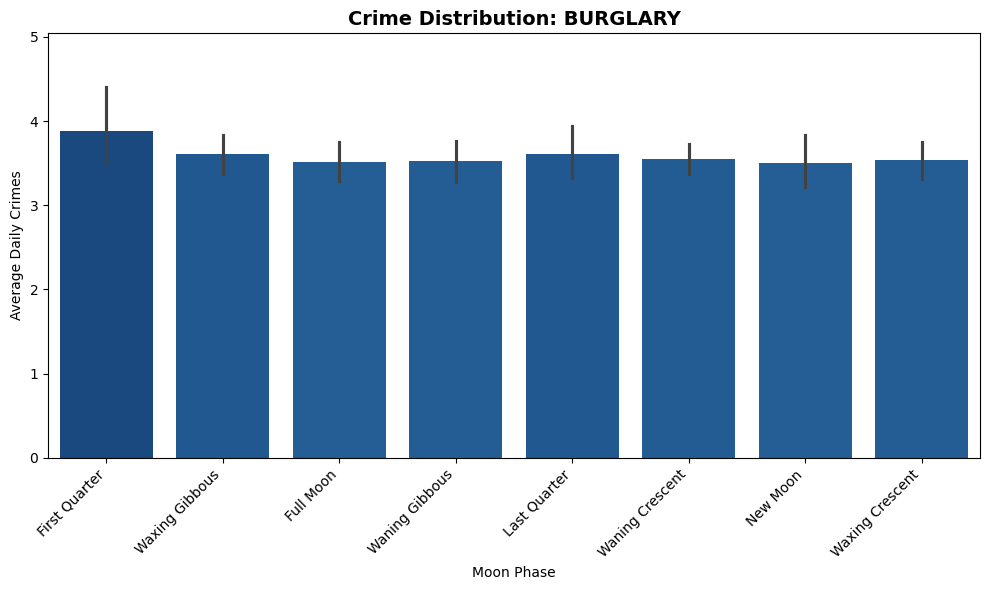

C:\Users\renat\AppData\Local\Temp\ipykernel_29296\4091705326.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Blues')


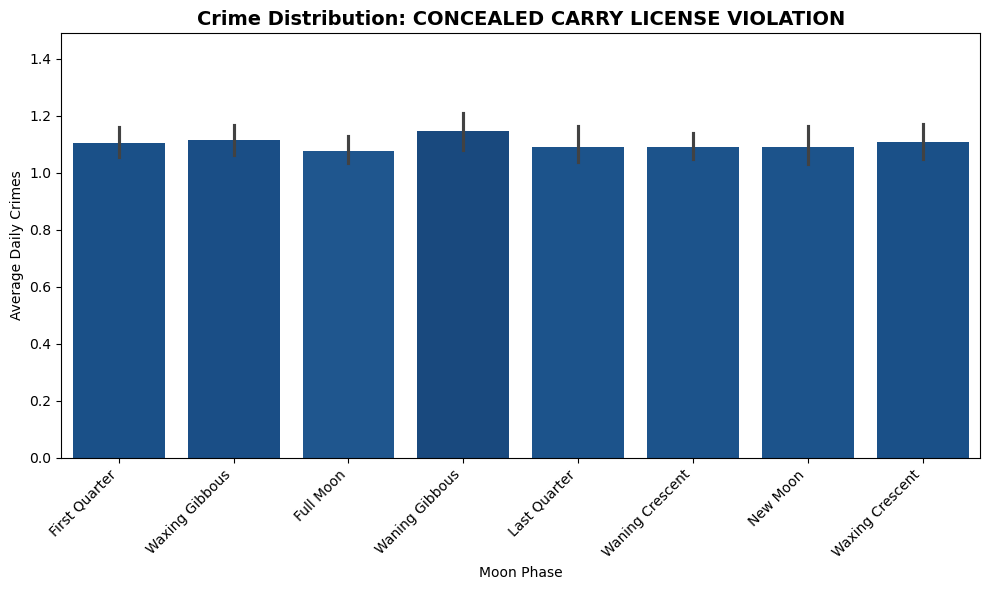

C:\Users\renat\AppData\Local\Temp\ipykernel_29296\4091705326.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Blues')


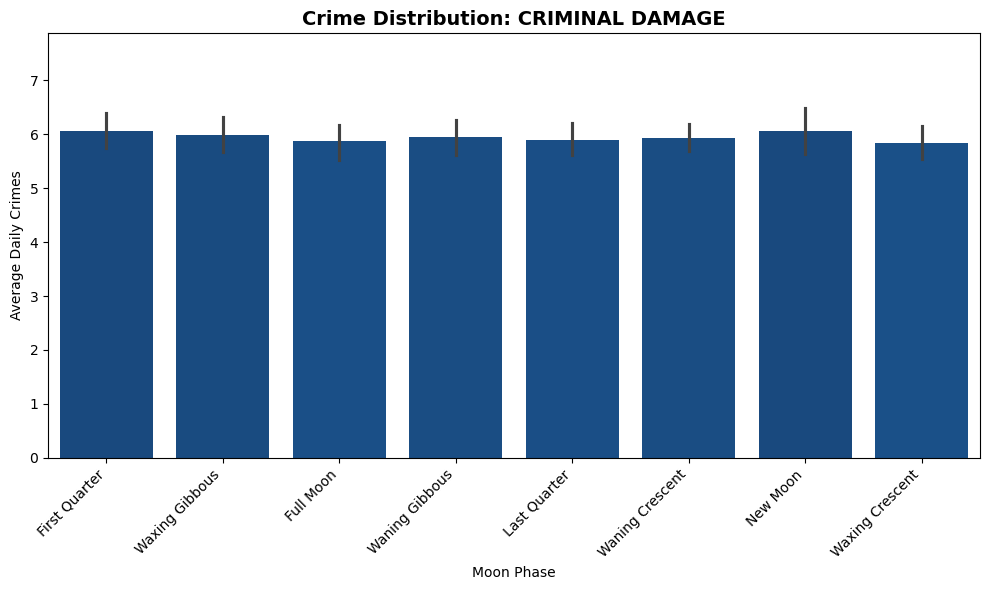

C:\Users\renat\AppData\Local\Temp\ipykernel_29296\4091705326.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Blues')


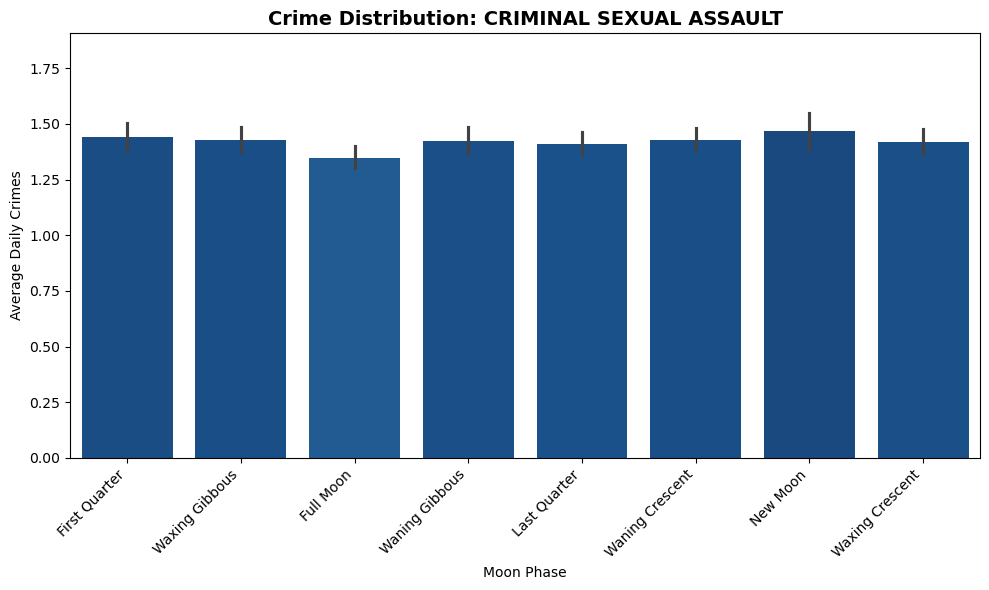

C:\Users\renat\AppData\Local\Temp\ipykernel_29296\4091705326.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Blues')


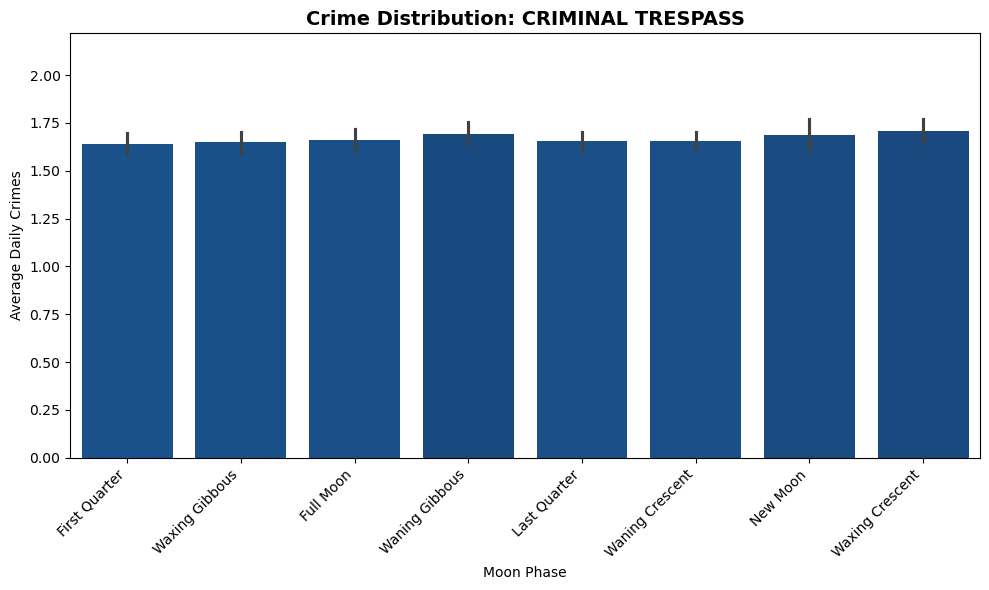

C:\Users\renat\AppData\Local\Temp\ipykernel_29296\4091705326.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Blues')


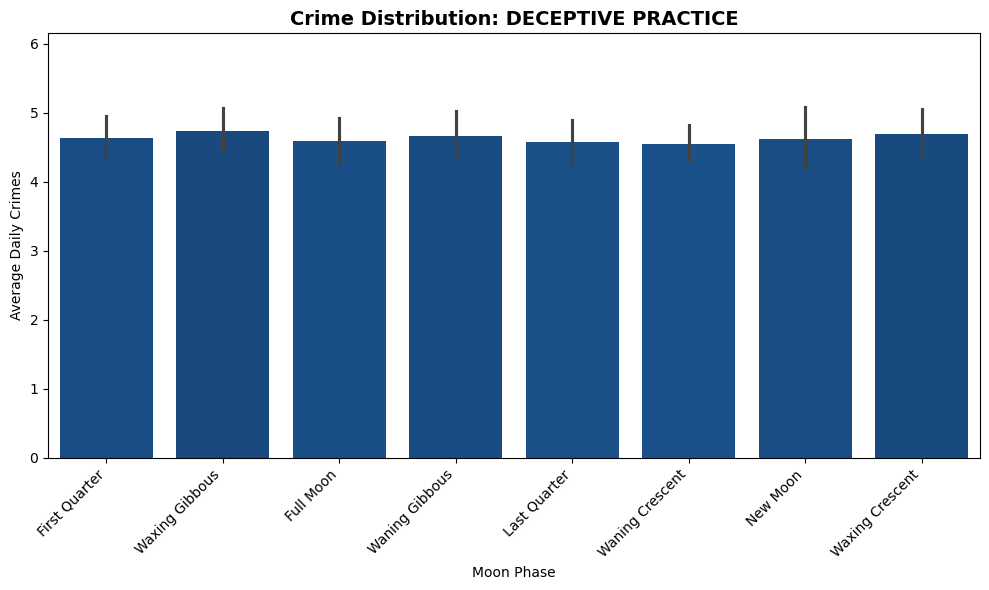

C:\Users\renat\AppData\Local\Temp\ipykernel_29296\4091705326.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Blues')


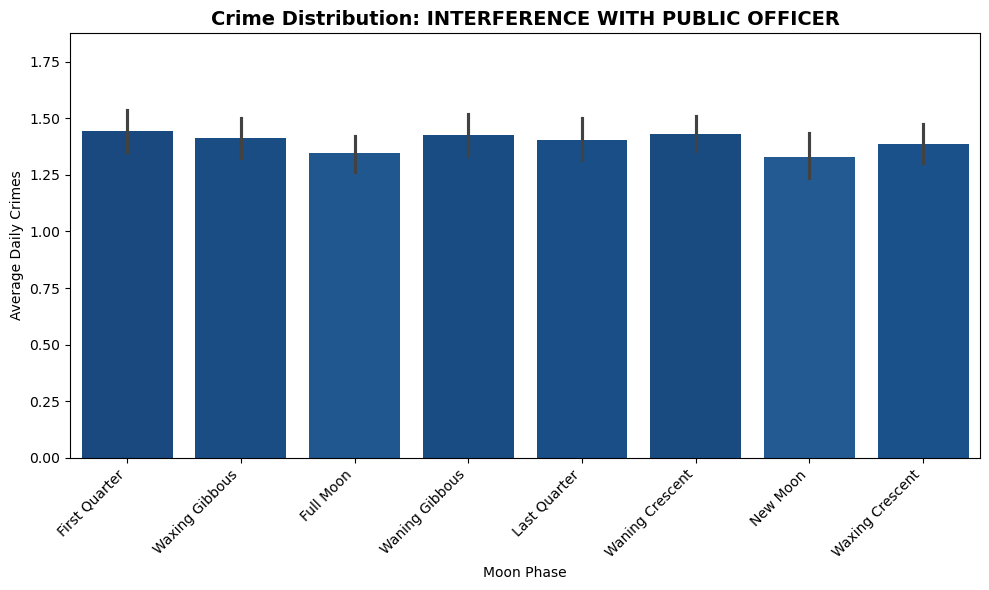

C:\Users\renat\AppData\Local\Temp\ipykernel_29296\4091705326.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Blues')


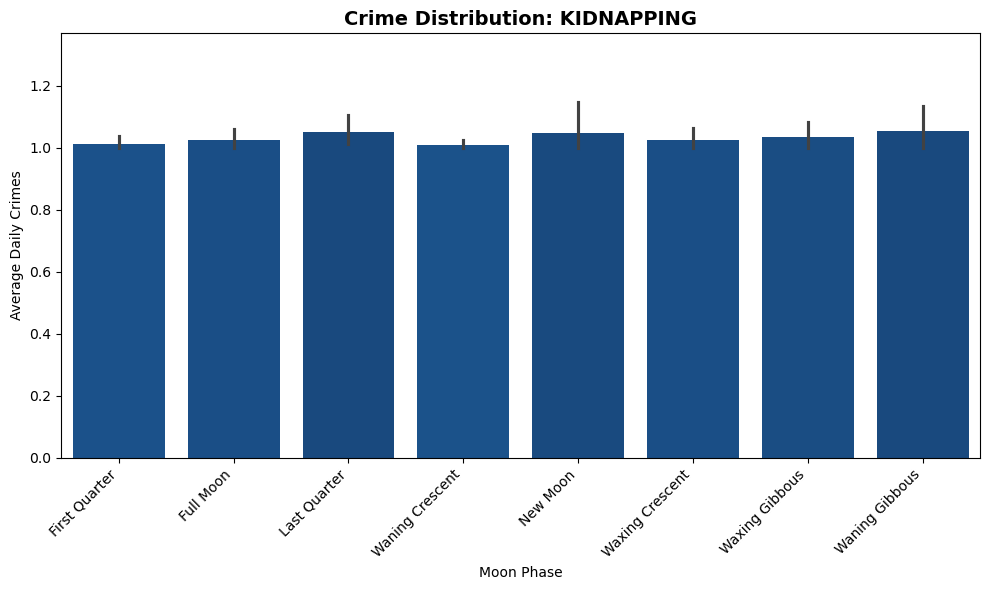

C:\Users\renat\AppData\Local\Temp\ipykernel_29296\4091705326.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Blues')


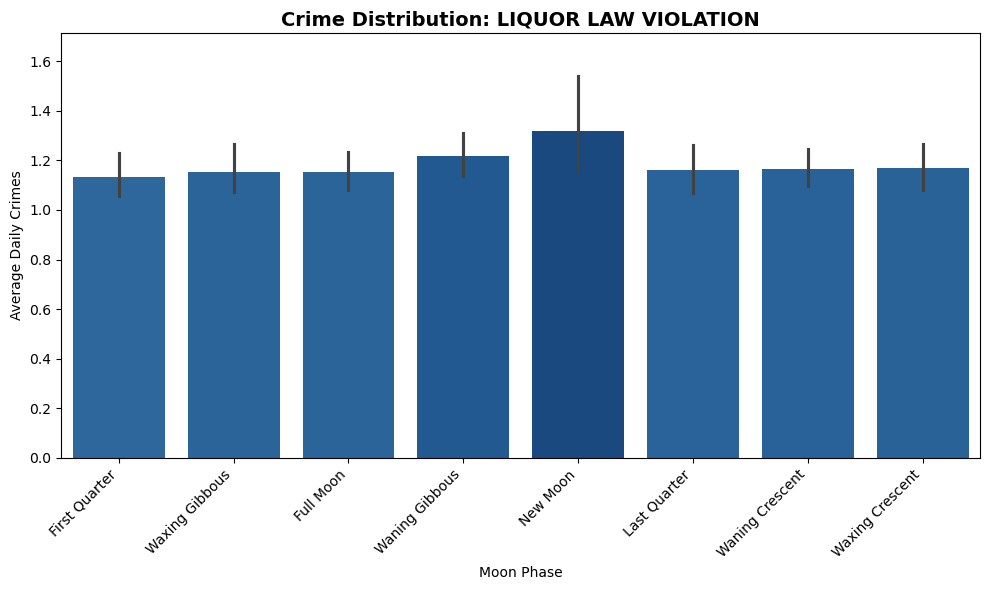

C:\Users\renat\AppData\Local\Temp\ipykernel_29296\4091705326.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Blues')


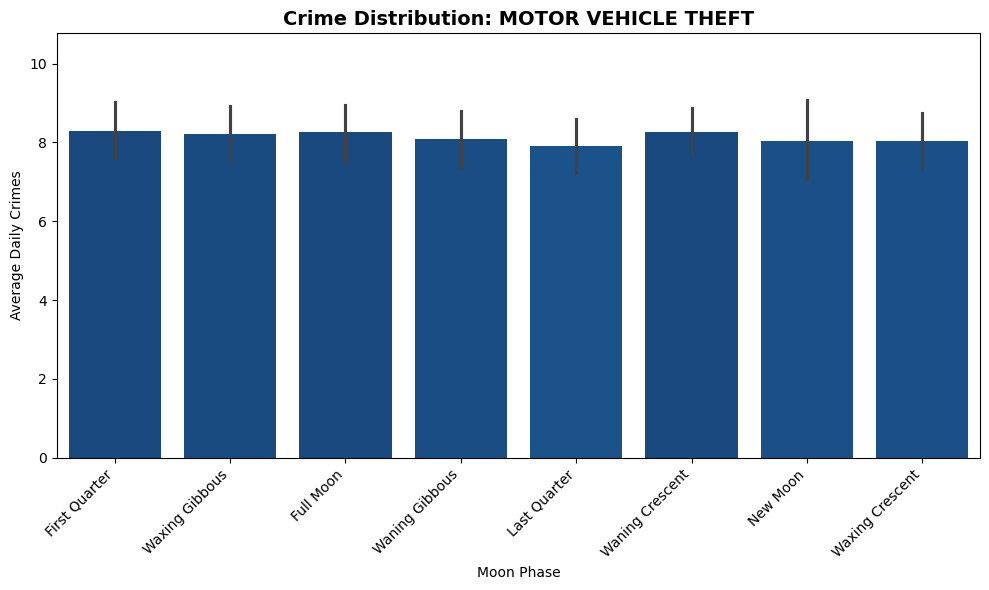

C:\Users\renat\AppData\Local\Temp\ipykernel_29296\4091705326.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Blues')


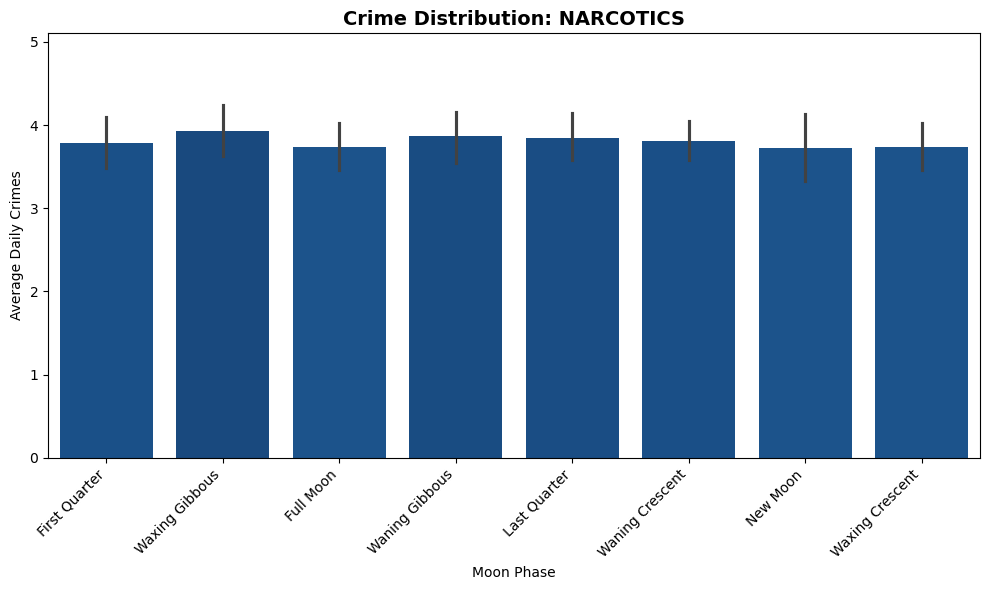

C:\Users\renat\AppData\Local\Temp\ipykernel_29296\4091705326.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Blues')


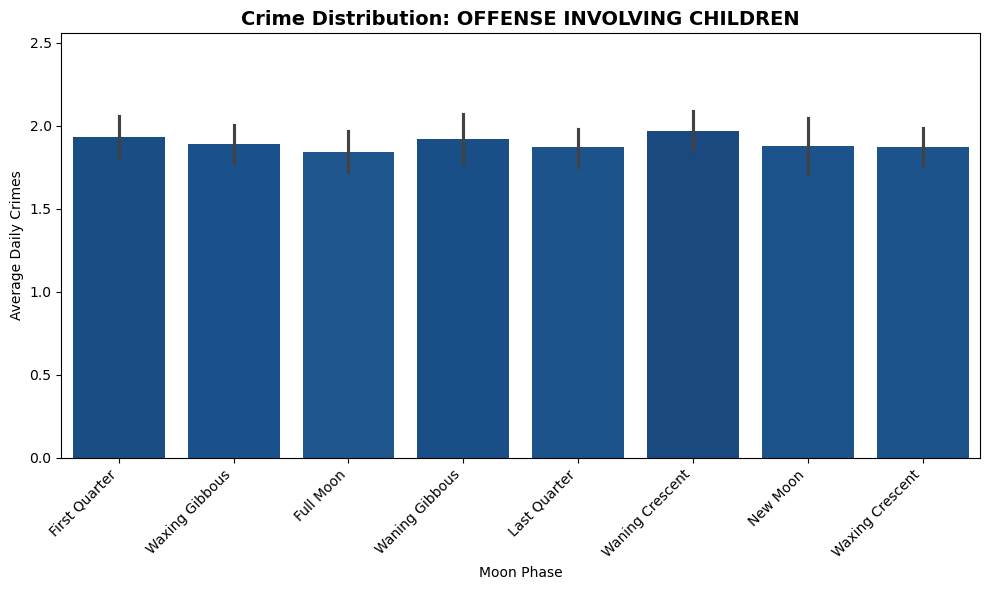

C:\Users\renat\AppData\Local\Temp\ipykernel_29296\4091705326.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Blues')


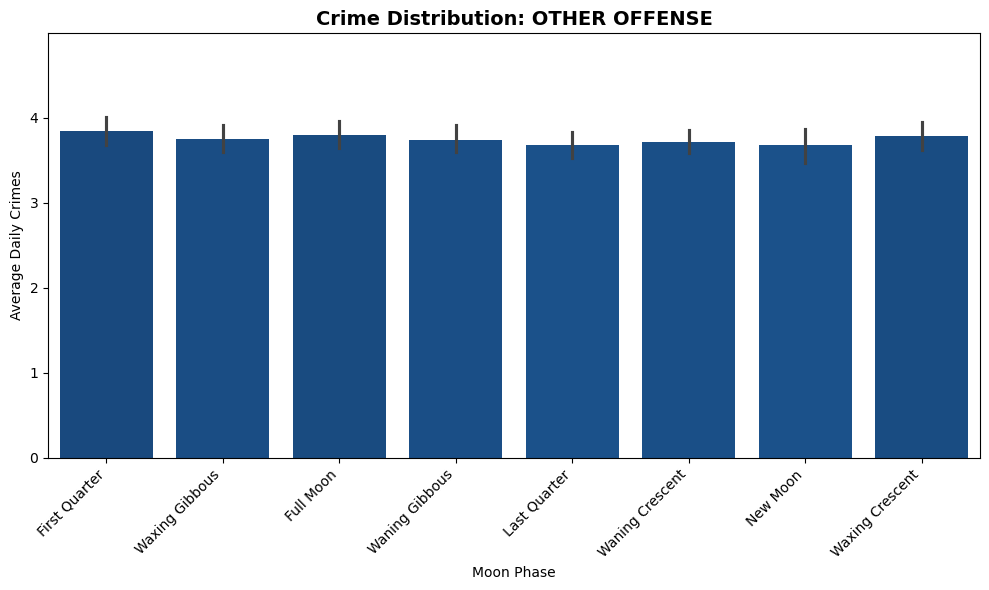

C:\Users\renat\AppData\Local\Temp\ipykernel_29296\4091705326.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Blues')


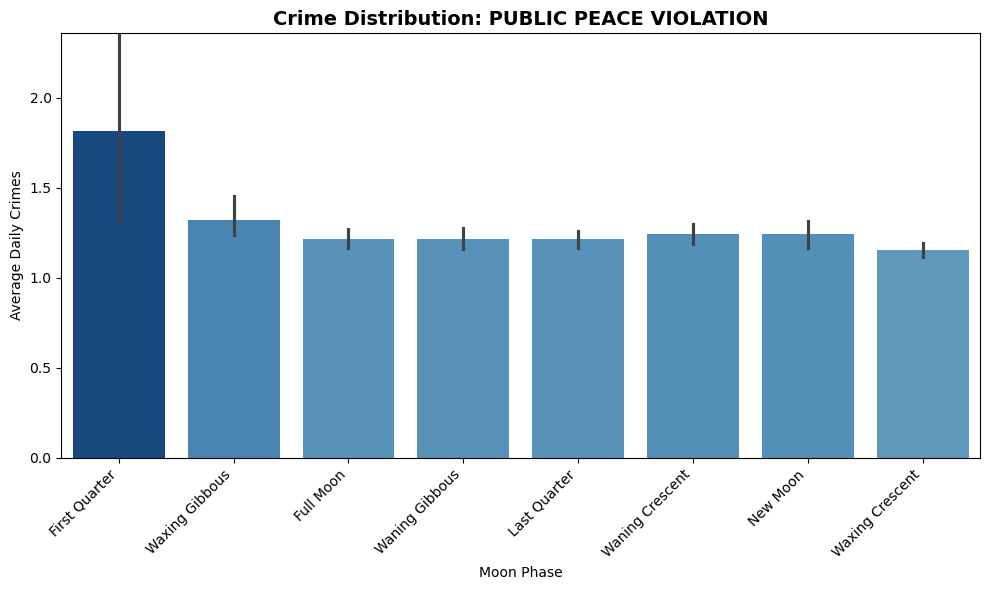

C:\Users\renat\AppData\Local\Temp\ipykernel_29296\4091705326.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Blues')


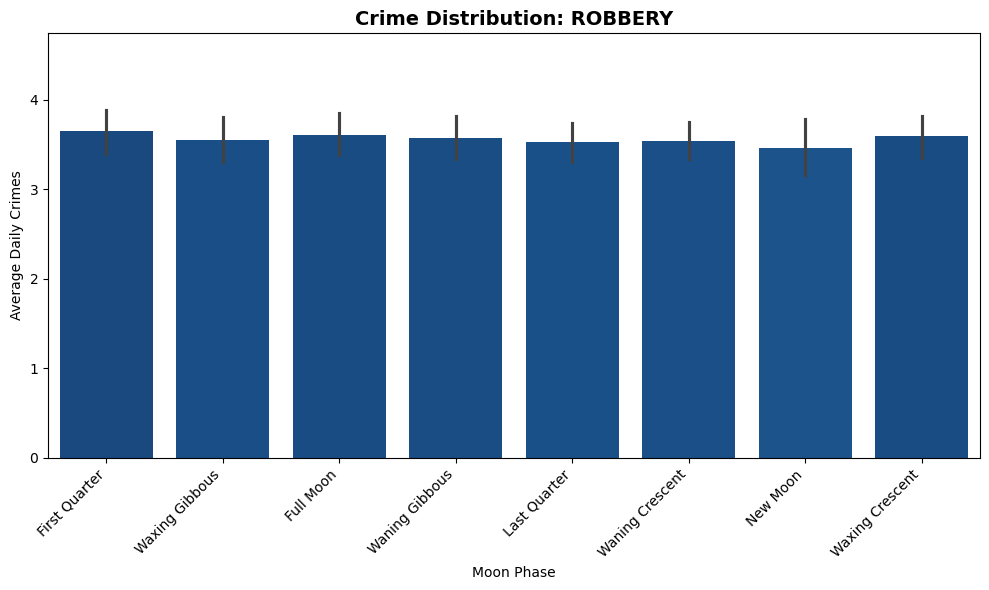

C:\Users\renat\AppData\Local\Temp\ipykernel_29296\4091705326.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Blues')


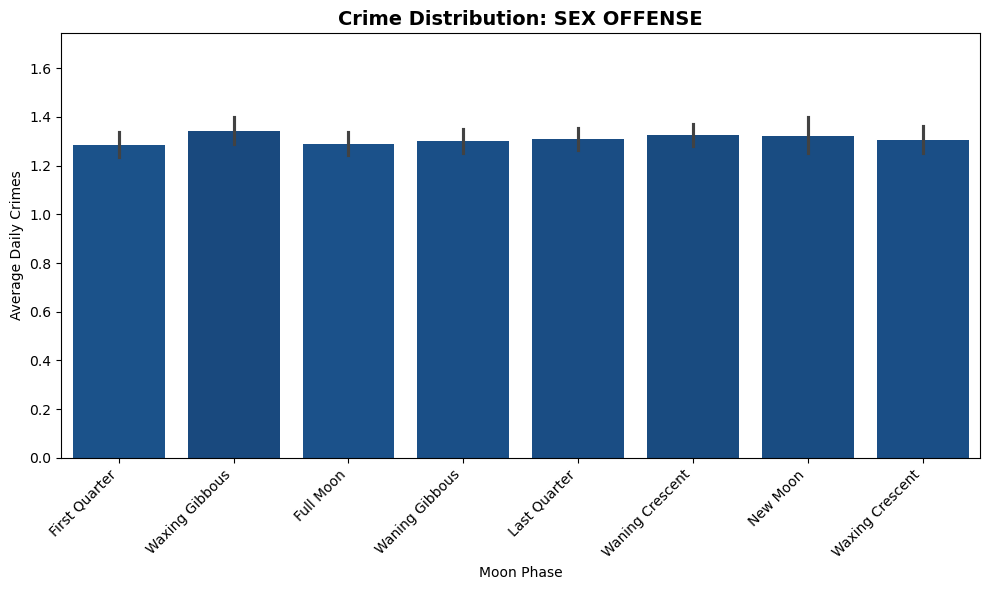

C:\Users\renat\AppData\Local\Temp\ipykernel_29296\4091705326.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Blues')


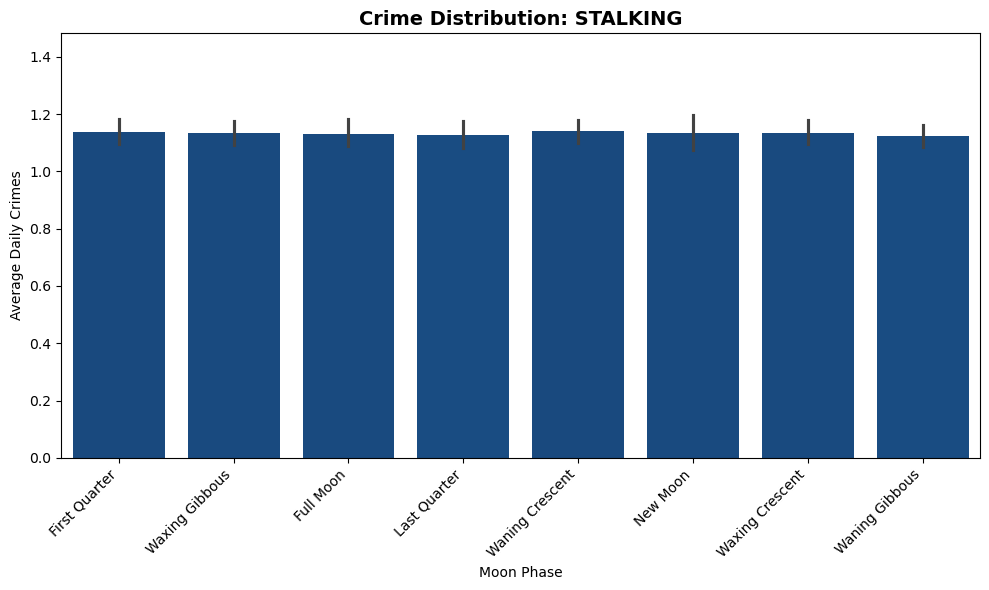

C:\Users\renat\AppData\Local\Temp\ipykernel_29296\4091705326.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Blues')


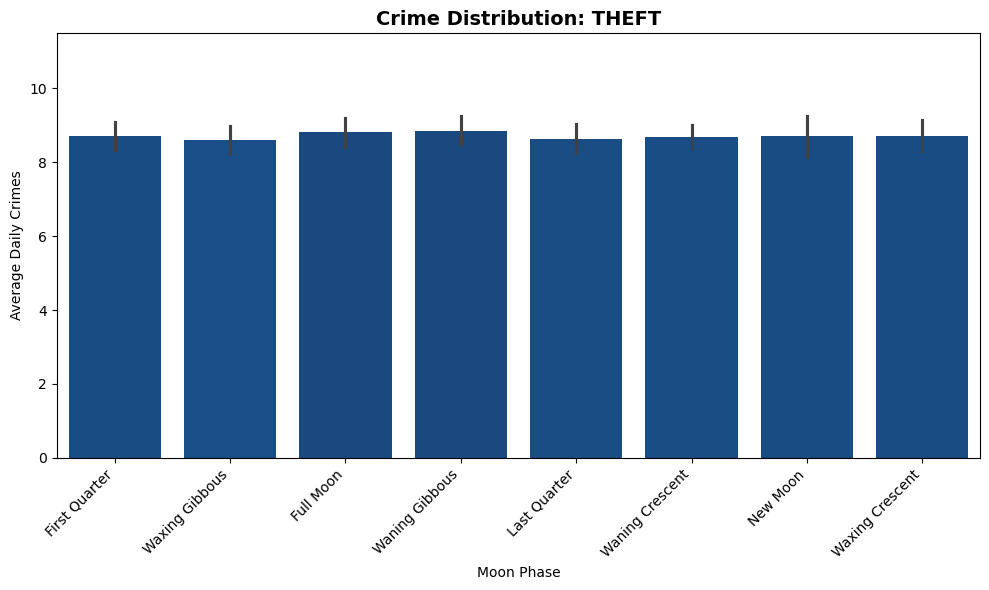

C:\Users\renat\AppData\Local\Temp\ipykernel_29296\4091705326.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Blues')


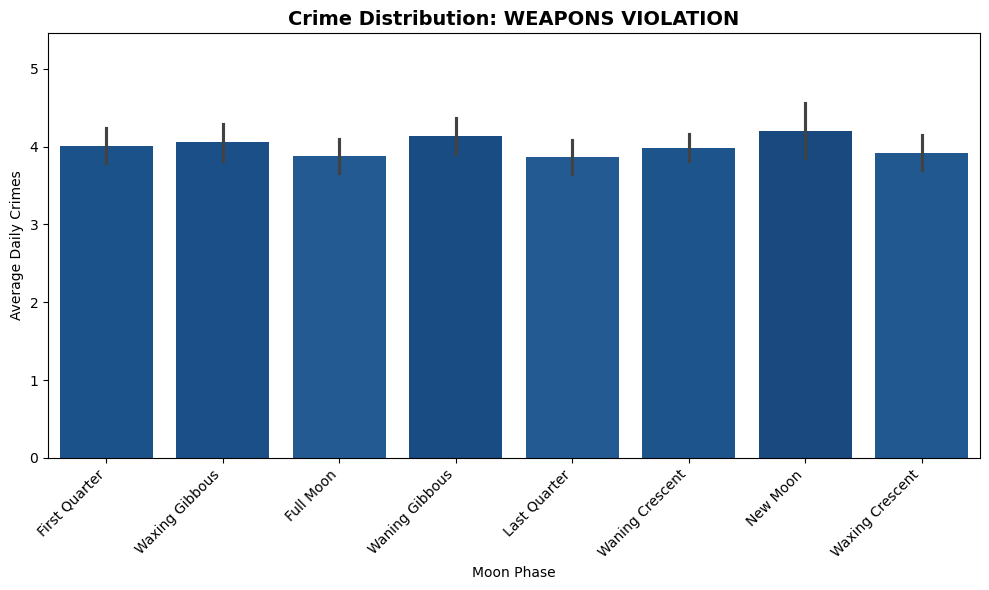

C:\Users\renat\AppData\Local\Temp\ipykernel_29296\4091705326.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Blues')


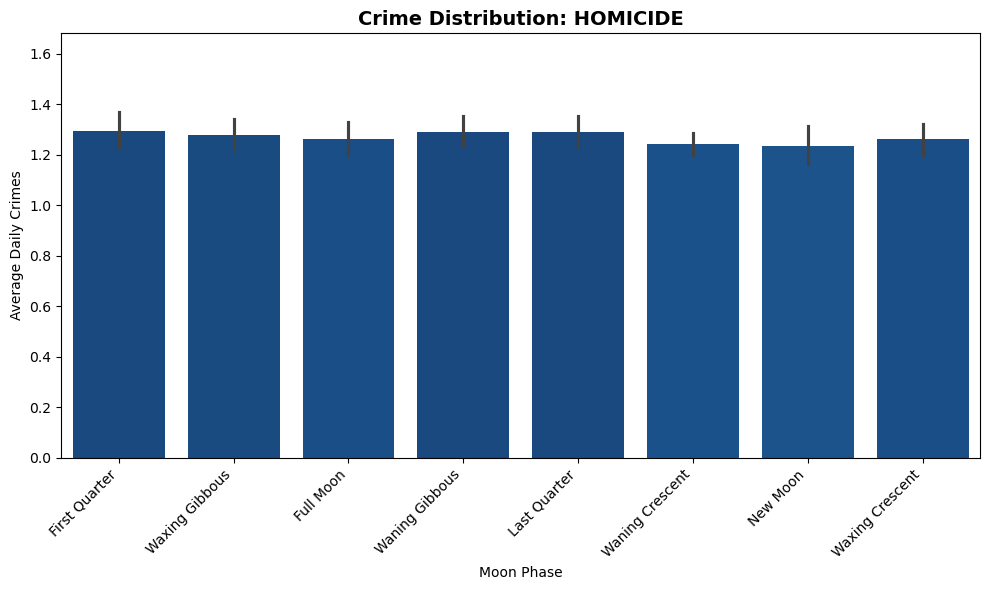

C:\Users\renat\AppData\Local\Temp\ipykernel_29296\4091705326.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Blues')


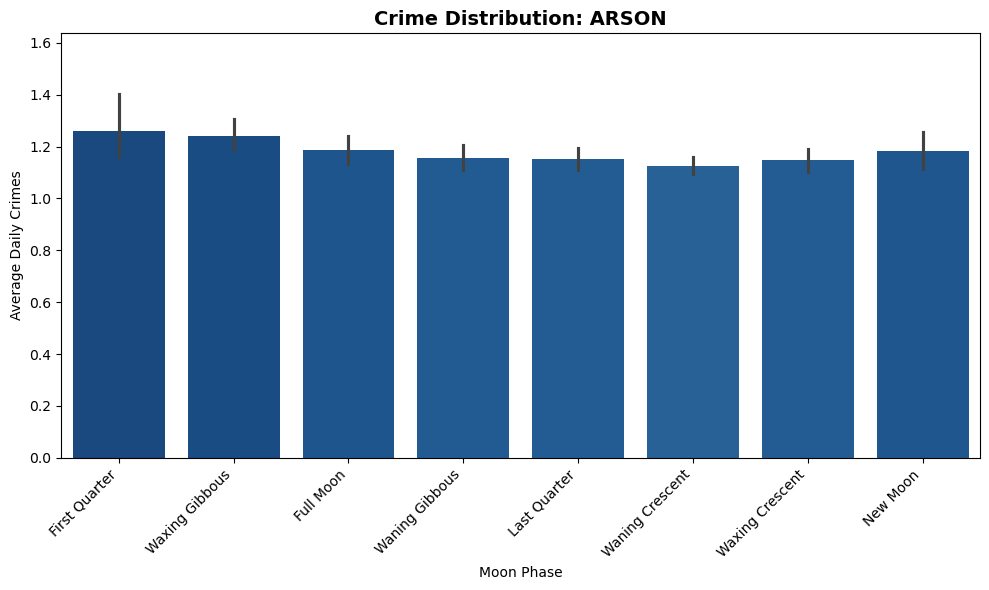

C:\Users\renat\AppData\Local\Temp\ipykernel_29296\4091705326.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Blues')


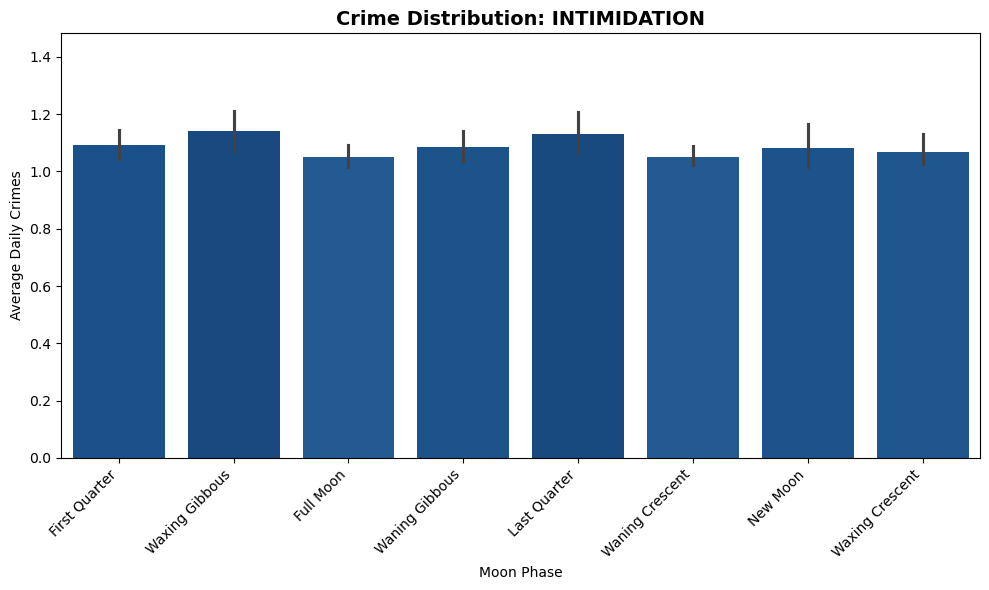

C:\Users\renat\AppData\Local\Temp\ipykernel_29296\4091705326.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Blues')


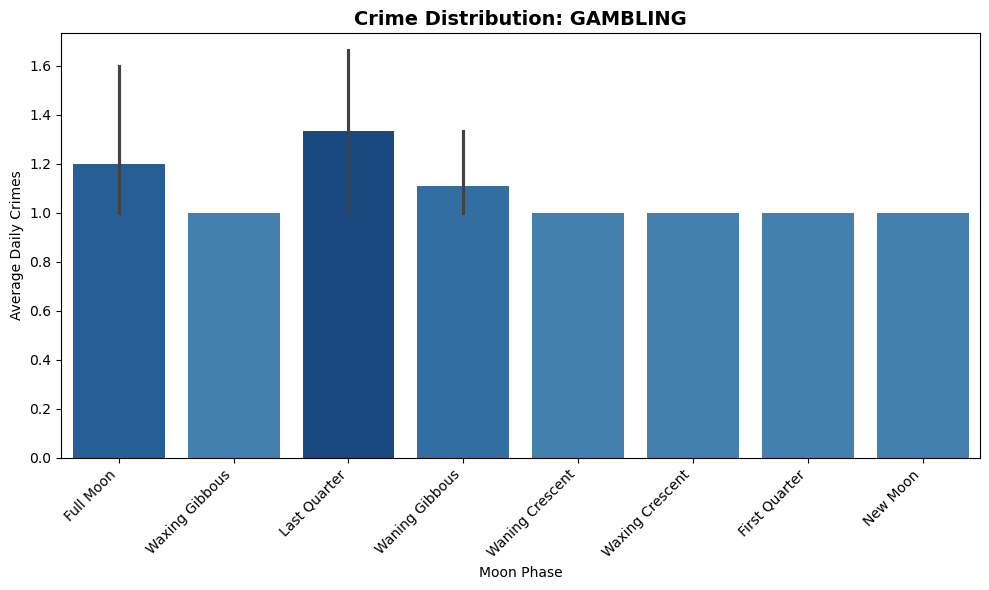

C:\Users\renat\AppData\Local\Temp\ipykernel_29296\4091705326.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Blues')


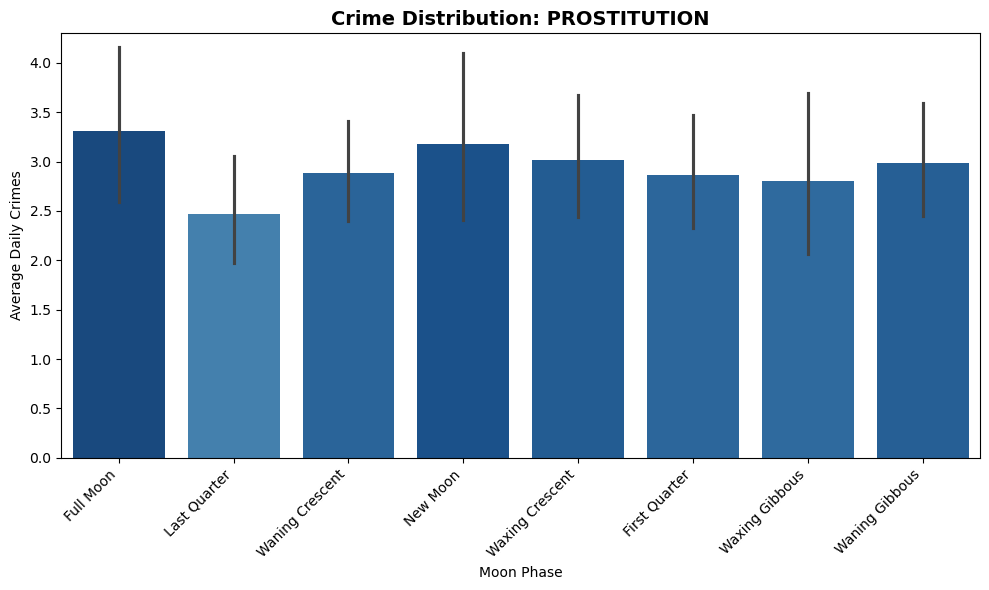

C:\Users\renat\AppData\Local\Temp\ipykernel_29296\4091705326.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Blues')


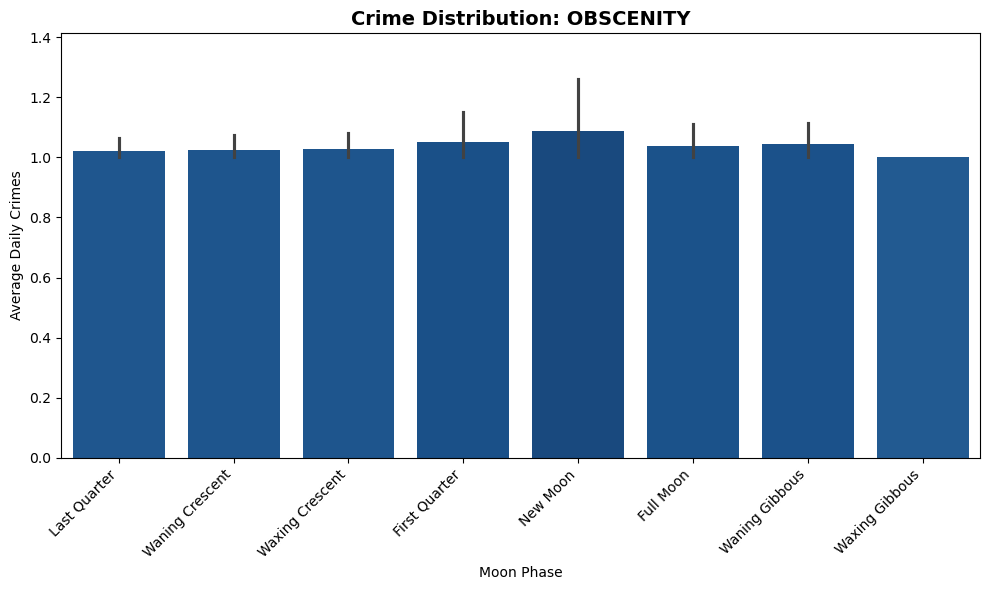

C:\Users\renat\AppData\Local\Temp\ipykernel_29296\4091705326.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Blues')


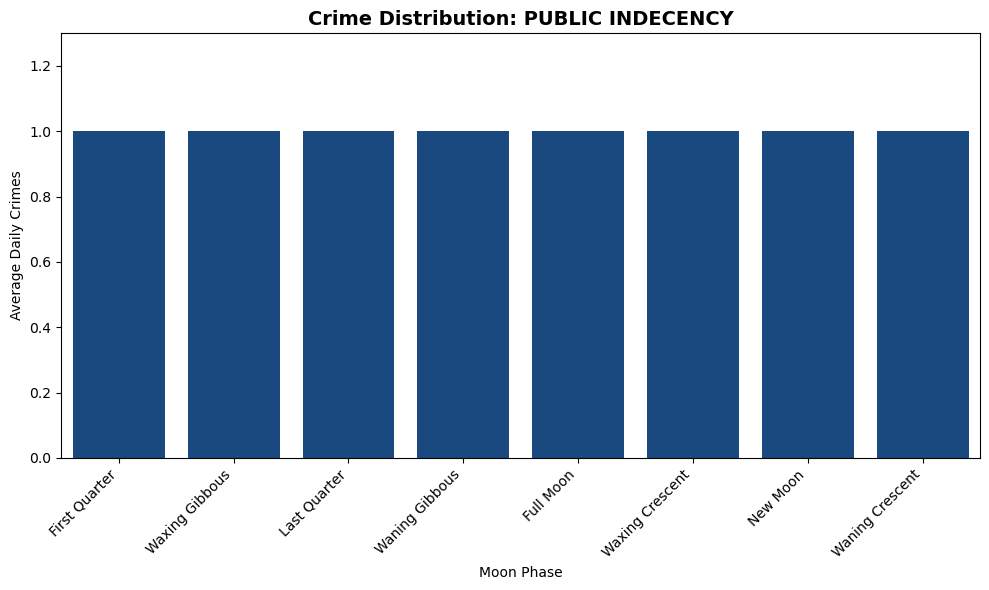

C:\Users\renat\AppData\Local\Temp\ipykernel_29296\4091705326.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Blues')


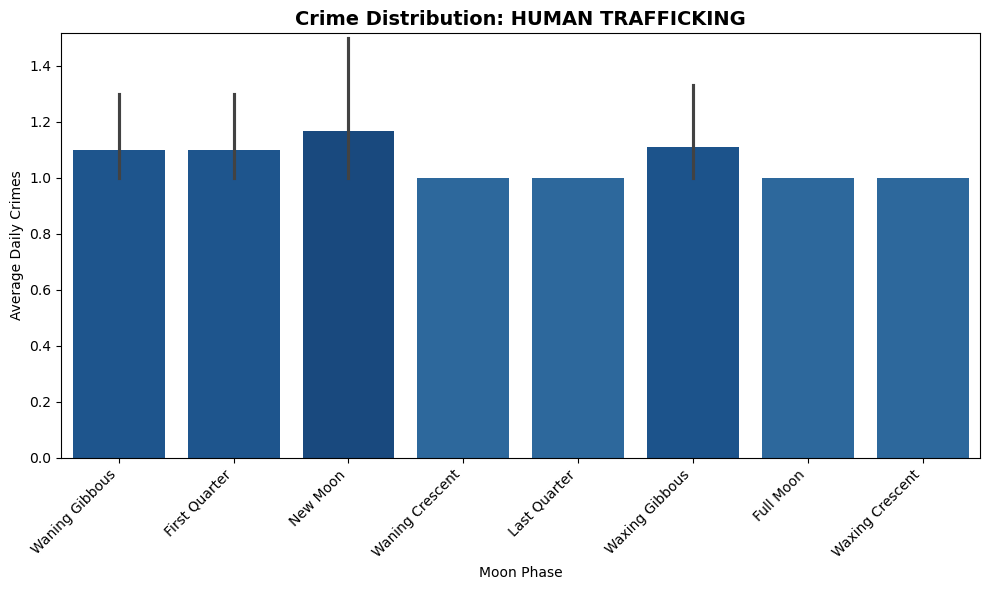

C:\Users\renat\AppData\Local\Temp\ipykernel_29296\4091705326.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Blues')


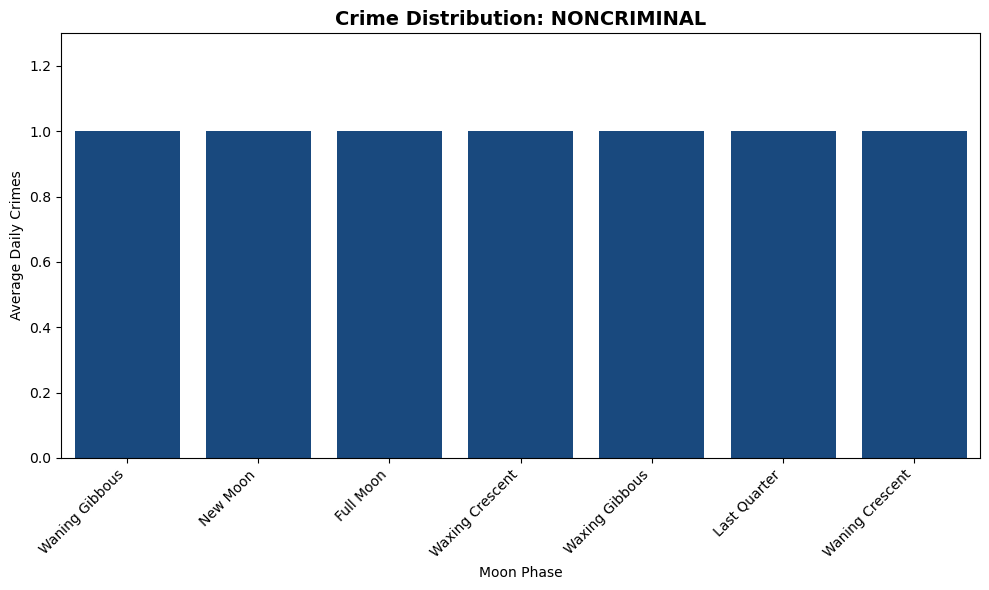

C:\Users\renat\AppData\Local\Temp\ipykernel_29296\4091705326.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Blues')


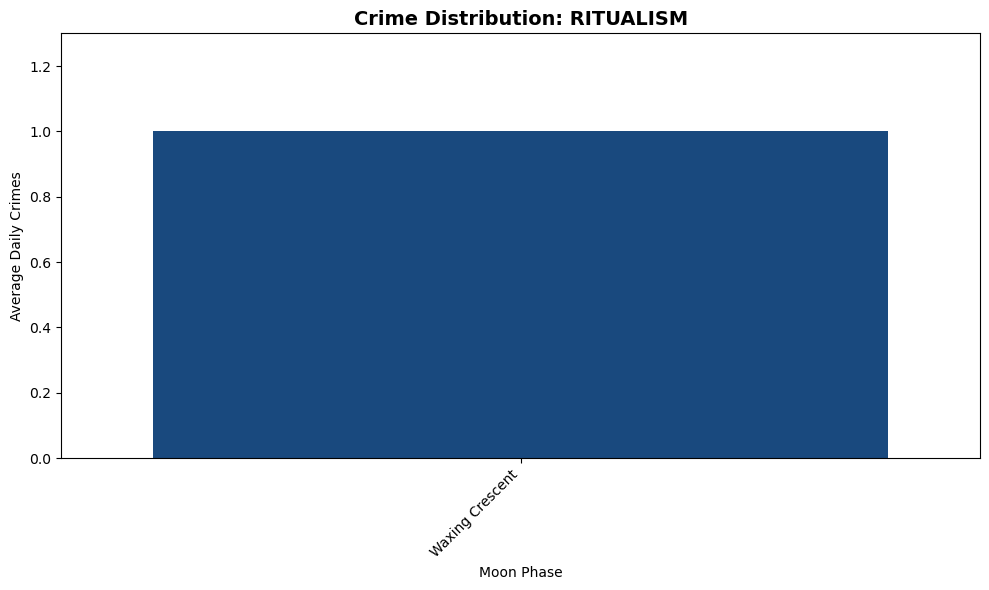

In [25]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

crime_types = merged['primary_type'].unique()

for crime in crime_types:
    crime_subset = merged[merged['primary_type'] == crime]
    
    phase_means = crime_subset.groupby('phase_str')['crime_count'].mean()
    norm = mcolors.Normalize(vmin=0, vmax=phase_means.max() * 1.1)
    colormap = cm.get_cmap('Blues') 
    
    custom_palette = {phase: colormap(norm(val)) for phase, val in phase_means.items()}
    
    plt.figure(figsize=(10, 6))
    
    ax = sns.barplot(
        data=crime_subset, 
        x='phase_str',
        y='crime_count',
        hue='phase_str',
        palette=custom_palette, 
        legend=False,
        errorbar=('ci', 95) 
    )
    
    plt.xticks(rotation=45, horizontalalignment='right')
    plt.title(f'Crime Distribution: {crime}', fontsize=14, fontweight='bold')
    plt.ylabel('Average Daily Crimes')
    plt.xlabel('Moon Phase')
    
    plt.ylim(0, phase_means.max() * 1.3)
    
    plt.tight_layout()
    plt.show()
  